In [8]:
import os
import zipfile

# Find and extract the uploaded zip file
zip_files = [f for f in os.listdir('/content') if f.endswith('.zip')]

if len(zip_files) > 0:
    zip_name = zip_files[0]
    print(f"Extracting {zip_name}...")
    with zipfile.ZipFile(f"/content/{zip_name}", 'r') as zip_ref:
        zip_ref.extractall('/content/dataset')
    print(" Extraction complete!")
else:
    print(" No zip file found. Please upload the dataset zip to the Files panel.")

Extracting archive.zip...
 Extraction complete!


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet import preprocess_input

train_dir = '/content/dataset/Training'
test_dir = '/content/dataset/Testing'

print("Setting up Augmented Image Generators...")

# Apply Data Augmentation to Training Data ONLY
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Testing data MUST remain untouched
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=32, class_mode='sparse', shuffle=False)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=32, class_mode='sparse', shuffle=False)

classes = list(train_generator.class_indices.keys())
print(f" Detected classes: {classes}")

Setting up Augmented Image Generators...
Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
 Detected classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [11]:
import numpy as np
from tensorflow.keras.applications import MobileNet
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Loading pre-trained MobileNetV1 model...")
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')

print("Extracting features from Training data...")
features_train = base_model.predict(train_generator)
y_train = train_generator.classes

print("Extracting features from Testing data...")
features_test = base_model.predict(test_generator)
y_test = test_generator.classes

print("Training the Support Vector Machine (Linear Kernel)...")
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(features_train, y_train)

print("Predicting and calculating metrics...")
y_pred_svm = svm_classifier.predict(features_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

print("-" * 50)
print("Approach 1 Results: DL Feature Extraction + SVM")
print("-" * 50)
print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F-measure: {f1_svm:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, target_names=classes))

Loading pre-trained MobileNetV1 model...
Extracting features from Training data...
175/175 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step
Extracting features from Testing data...
50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step
Training the Support Vector Machine (Linear Kernel)...
Predicting and calculating metrics...
--------------------------------------------------
Approach 1 Results: DL Feature Extraction + SVM
--------------------------------------------------
Accuracy:  0.9006
Precision: 0.8999
Recall:    0.9006
F-measure: 0.8986

Classification Report:
               precision    recall  f1-score   support

      glioma       0.91      0.79      0.85       400
  meningioma       0.84      0.82      0.83       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.91      0.98      0.95       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



In [12]:
import numpy as np
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Reset generators to ensure labels align correctly
train_generator.reset()
test_generator.reset()

print("Building End-to-End MobileNetV1 Model...")
base_model_e2e = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')
base_model_e2e.trainable = False # Freeze base layers

# Add custom dense layers for the 4 specific tumor classes
x = base_model_e2e.output
x = Dropout(0.2)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model_e2e.input, outputs=predictions)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training End-to-End model (5 Epochs)...")
history = model.fit(train_generator, epochs=5, validation_data=test_generator)

print("Predicting and calculating metrics...")
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred_e2e = np.argmax(y_pred_probs, axis=1)
y_test_e2e = test_generator.classes

accuracy_e2e = accuracy_score(y_test_e2e, y_pred_e2e)
precision_e2e = precision_score(y_test_e2e, y_pred_e2e, average='weighted')
recall_e2e = recall_score(y_test_e2e, y_pred_e2e, average='weighted')
f1_e2e = f1_score(y_test_e2e, y_pred_e2e, average='weighted')
conf_matrix_e2e = confusion_matrix(y_test_e2e, y_pred_e2e)

print("-" * 50)
print("Approach 2 Results: End-to-End Deep Learning Model")
print("-" * 50)
print(f"Accuracy:  {accuracy_e2e:.4f}")
print(f"Precision: {precision_e2e:.4f}")
print(f"Recall:    {recall_e2e:.4f}")
print(f"F-measure: {f1_e2e:.4f}")
print("\nClassification Report:\n", classification_report(y_test_e2e, y_pred_e2e, target_names=classes))

Building End-to-End MobileNetV1 Model...
Training End-to-End model (5 Epochs)...
Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.6004 - loss: 1.0466 - val_accuracy: 0.7113 - val_loss: 0.7258
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.7670 - loss: 0.6088 - val_accuracy: 0.7912 - val_loss: 0.5894
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.8282 - loss: 0.4761 - val_accuracy: 0.7650 - val_loss: 0.6188
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - accuracy: 0.8371 - loss: 0.4336 - val_accuracy: 0.8325 - val_loss: 0.4892
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.8586 - loss: 0.3868 - val_accuracy: 0.8306 - val_loss: 0.5060
Predicting and calculating metrics...
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step
--------------------------------------------------
Approach 2 Results: End-to-End Deep Learning Model
--------------------------------------------------
Accuracy:  0.8306
Precision: 0.8346
Recall:    0.

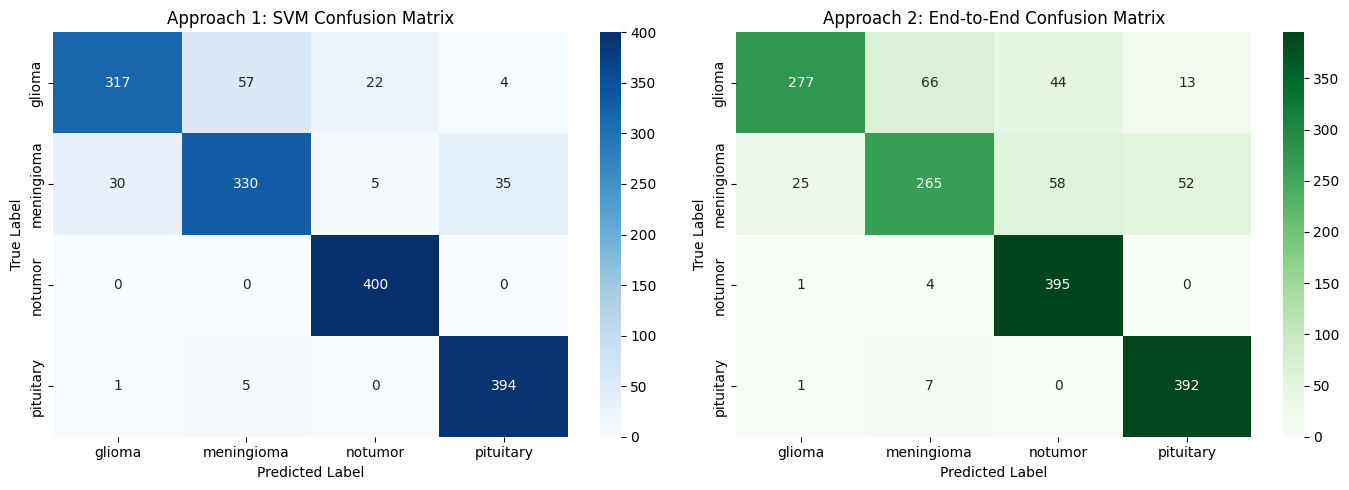

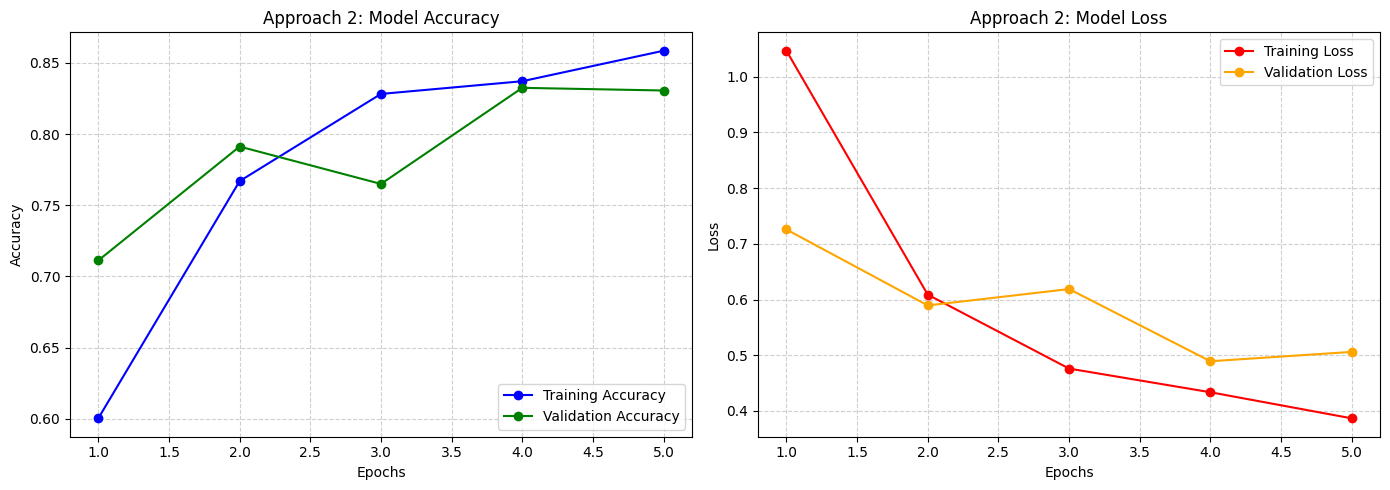

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- 1. Plot Confusion Matrices ----
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Approach 1: SVM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_e2e, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title('Approach 2: End-to-End Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ---- 2. Plot Learning Curves for Approach 2 ----
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='green', marker='o')
plt.title('Approach 2: Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='red', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='o')
plt.title('Approach 2: Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()